# Calibrating the the Incubator Temperature Dynamics

## Step 1: Get the calibration data

The data comes from an experiment where the heater was turned on, letting the incubator warm up for some time, and then turned off, before repeating.

In [1]:
# Get CSV file from an incubator dataset
import os

# Get the current working directory.
current_dir = os.getcwd()

assert os.path.basename(current_dir) == '4-Calibration', 'Current directory is not 4-Calibration'

# Get the parent directory. Should be the root of the repository
parent_dir = os.path.dirname(current_dir)

# The root of the repo should contain the incubator_dt folder. Otherwise something went wrong in 0-Pre-requisites.
assert os.path.exists(os.path.join(parent_dir, 'incubator_dt')), 'incubator_dt folder not found in the repository root'

csv_file_path = os.path.join(parent_dir, 'incubator_dt', 'software', 'incubator', 'datasets', '20230501_calibration_empty_system', '20230501_calibration_empty_system.csv')

assert os.path.exists(csv_file_path), '20230501_calibration_empty_system.csv not found in the incubator repository.'

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv(csv_file_path)
data.head()

,time,t1,time_t1,t2,time_t2,t3,time_t3,average_temperature,heater_on,fan_on,execution_interval,elapsed
0,1682912554273107499,23.062,1682912554192856639,24.312,1682912554232822932,22.125,1682912554272705263,23.6870,False,False,3.0,1.025402
1,1682912557313698460,23.062,1682912557272792494,24.375,1682912557232848441,22.125,1682912557313344724,23.7185,False,False,3.0,1.064928
2,1682912560282455551,23.062,1682912560232232220,24.375,1682912560192178595,22.062,1682912560282224276,23.7185,False,False,3.0,1.031638
3,1682912563313803672,23.125,1682912563273056592,24.375,1682912563232827969,22.062,1682912563313317234,23.7500,False,False,3.0,1.061013
4,1682912566283347240,23.125,1682912566243313892,24.375,1682912566192896637,22.062,1682912566282895616,23.7500,False,False,3.0,1.028555


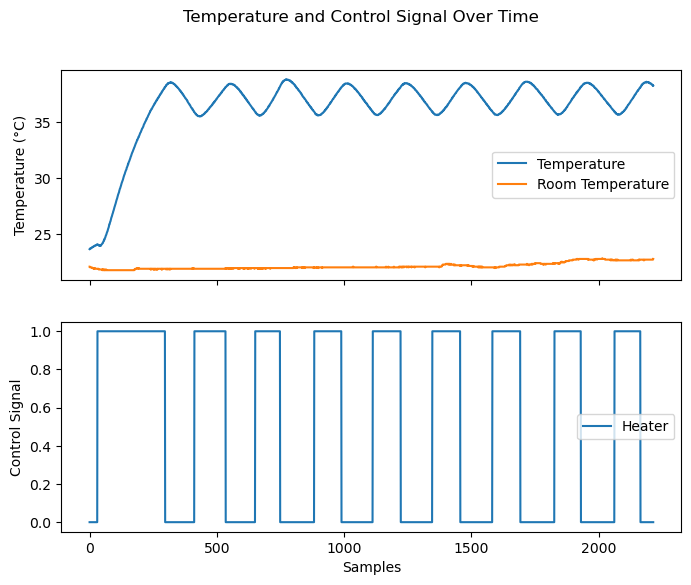

In [3]:
# Create subplots with shared X-axis for temperature and control signal.
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

# Plot temperature data on the first subplot
ax1.plot(data.index, data.average_temperature, label='Temperature')
ax1.plot(data.index, data.t3, label='Room Temperature')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()

# Plot control signal data on the second subplot (heater on/off)
ax2.plot(data.index, data.heater_on, label='Heater')
ax2.set_xlabel('Samples')
ax2.set_ylabel('Control Signal')
ax2.legend()

# Add a title to the shared X-axis
fig.suptitle('Temperature and Control Signal Over Time')

# Show the plots
plt.show()

## Step 2: Define the ODE System for the Incubator

We reuse the model created in [3-Physics-Modelling\2-ModellingIncubatorDynamics.ipynb](..\3-Physics-Modelling\2-ModellingIncubatorDynamics.ipynb), extended with the interpolated continuous functions from the dataset.

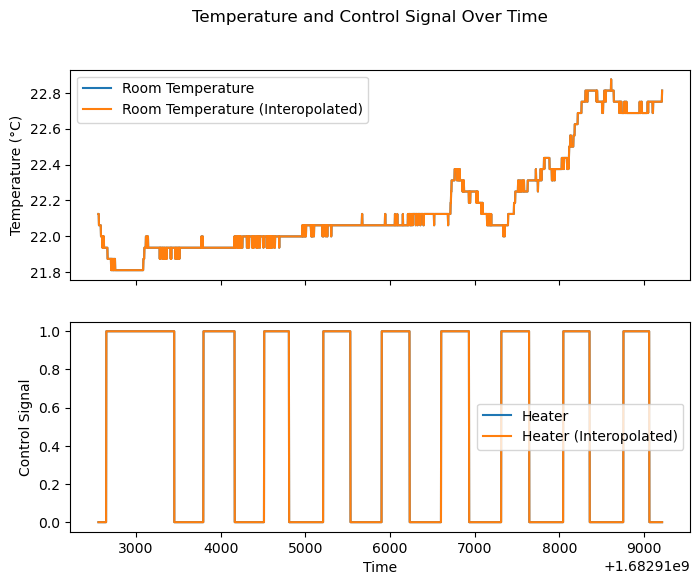

In [4]:
# Example of a varying power and room temperature
from scipy.interpolate import interp1d
import numpy as np

# Create lookup functions for model inputs from the data.
time_range = data["time"].to_numpy().astype(np.float64)

# Time has been stored in nanoseconds, so we need to convert it to seconds
time_range = time_range / 1e9

# interp1d returns a function of time, 
#  that finds the closest value in the data to the time given.
# This is useful for interpolating the data to the time steps of the model, when estimating the model parameters.
heater_on_lookup_function = interp1d(time_range, data["heater_on"].to_numpy())
T_room_lookup_function = interp1d(time_range, data["t3"].to_numpy())

# Plot interpolated data vs original data. It should be fairly close.
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
# Plot temperature data on the first subplot
ax1.plot(time_range, data.t3, label='Room Temperature')
ax1.plot(time_range, [T_room_lookup_function(t) for t in time_range], label='Room Temperature (Interopolated)')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()

# Plot control signal data on the second subplot (heater on/off)
ax2.plot(time_range, data.heater_on, label='Heater')
ax2.plot(time_range, [heater_on_lookup_function(t) for t in time_range], label='Heater (Interopolated)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Control Signal')
ax2.legend()

# Add a title to the shared X-axis
fig.suptitle('Temperature and Control Signal Over Time')

# Show the plots
plt.show()

In [5]:
from scipy.integrate import solve_ivp

# ODE system
def incubator_ode_with_varying_conditions(t, y, Ch, Cb, G_hb, G_br, Voltage, Current):
    Th, Tb = y
    Ph = Voltage*Current  # Power in (W)
    Tr = T_room_lookup_function(t)  # Interpolated room temperature at time t
    H_h = heater_on_lookup_function(t)  # Heater on/off switch at time t
    dTh_dt = (H_h * Ph - G_hb * (Th - Tb)) / Ch
    dTb_dt = (G_hb * (Th - Tb) - G_br * (Tb - Tr)) / Cb
    return [dTh_dt, dTb_dt]

# Parameters (arbitrary values for demonstration purposes)
Ch = 500.0  # Heat capacity of the heater (J/Kg/C)
Cb = 1000.0  # Heat capacity of the box (J/Kg/C)
G_hb = 10.0  # Heat transfer coefficient between heater and box (W/C)
G_br = 5.0  # Heat transfer coefficient between box and room (W/C)
Voltage = 12.0  # Voltage of the Heater (V)
Current = 1.5  # Current of the Heater (A)

# Initial conditions
T_h0 = data.average_temperature[0]  # Initial heater temperature (C). Assumed to be the same as the initial box temperature and comes from initial value of the data.
T_b0 = data.average_temperature[0]  # Initial box temperature (C)
y0 = [T_h0, T_b0]  # Initial state vector

# Time span: same as the dataset
t_span = (time_range[0], time_range[-1])  # Start and end times
t_eval = time_range  # Times at which to evaluate the solution. Should match the dataset.

sol = solve_ivp(
        lambda t, y: incubator_ode_with_varying_conditions(t, y, Ch, Cb, G_hb, G_br, Voltage, Current),
        t_span, y0, t_eval=t_eval)

sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 1.683e+09  1.683e+09 ...  1.683e+09  1.683e+09]
        y: [[ 2.369e+01  2.369e+01 ...  2.478e+01  2.476e+01]
            [ 2.369e+01  2.366e+01 ...  2.443e+01  2.441e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 824
     njev: 0
      nlu: 0

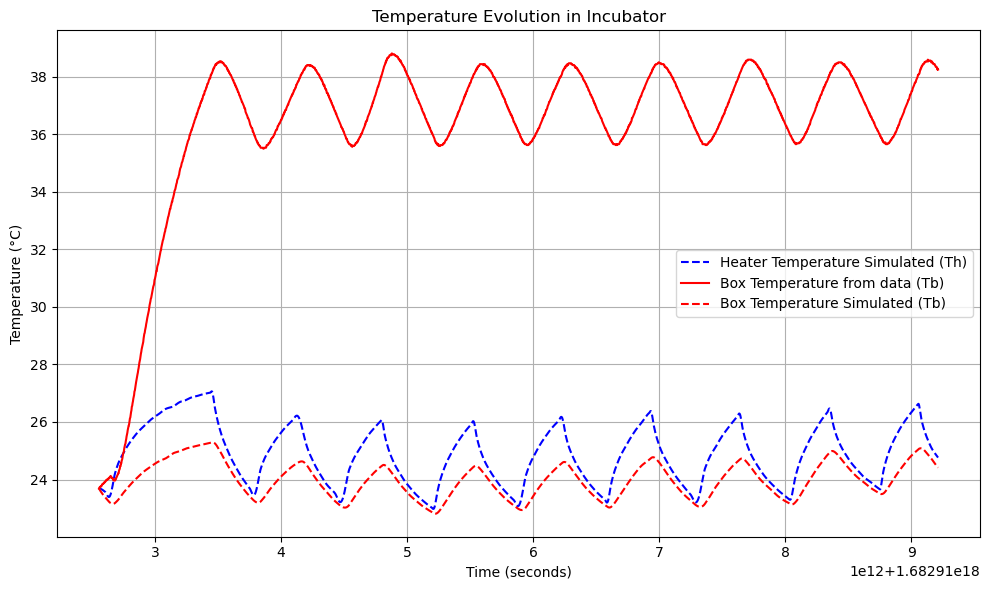

In [6]:
# Plot the results
Th_values = sol.y[0,:]
Tb_values = sol.y[1,:]

plt.figure(figsize=(10, 6))
plt.plot(data.time, Th_values, color='blue', linestyle="--", label='Heater Temperature Simulated (Th)')
plt.plot(data.time, data.average_temperature, color='red', label='Box Temperature from data (Tb)')
plt.plot(data.time, Tb_values, color='red', linestyle="--", label='Box Temperature Simulated (Tb)')
plt.title('Temperature Evolution in Incubator')
plt.xlabel('Time (seconds)')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Now let us try out different values of some of the ODE parameters. Our goal is to make the dashed red line (simulated temperature of the box) match the continuous red line (temperature from the dataset).

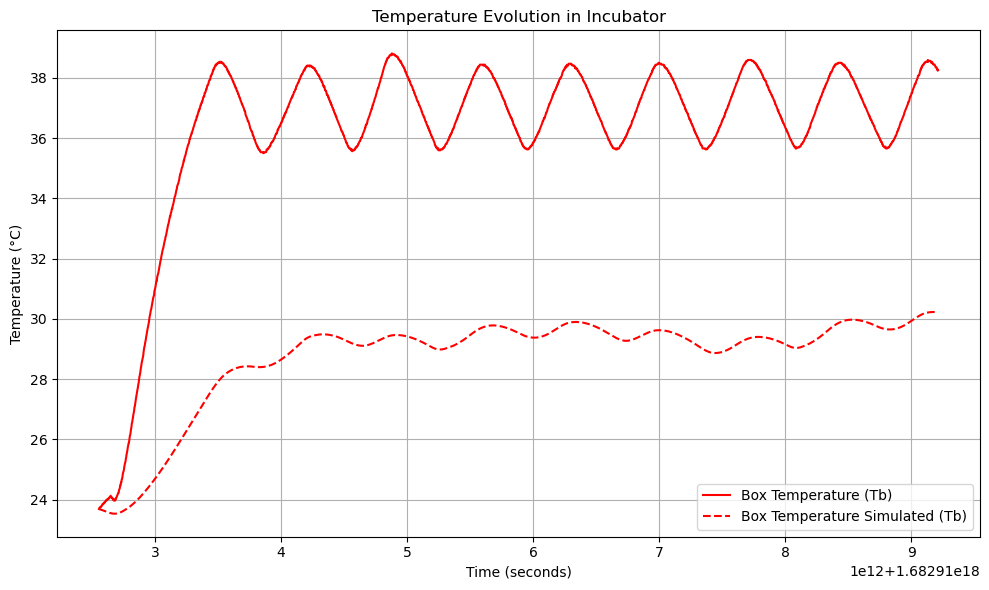

In [7]:
# Try changing the following values. As a first suggestion, we've decreased the values of the G_hb and G_br parameter.
Ch = 500.0  # Heat capacity of the heater (J/Kg/C)
Cb = 1000.0  # Heat capacity of the box (J/Kg/C)
G_hb = 1.0  # Heat transfer coefficient between heater and box (W/C)
G_br = 1.0  # Heat transfer coefficient between box and room (W/C)
Voltage = 12  # Voltage of the Heater (V)
Current = 1.5  # Current of the Heater (A)

sol = solve_ivp(
        lambda t, y: incubator_ode_with_varying_conditions(t, y, Ch, Cb, G_hb, G_br, Voltage, Current),
        t_span, y0, t_eval=t_eval)

Th_values = sol.y[0,:]
Tb_values = sol.y[1,:]

plt.figure(figsize=(10, 6))
# Omit heater temperature as not important since we do not have heater temperature data
# plt.plot(data.time, Th_values, color='blue', label='Heater Temperature (Th)')
plt.plot(data.time, data.average_temperature, color='red', label='Box Temperature (Tb)')
plt.plot(data.time, Tb_values, color='red', linestyle="--", label='Box Temperature Simulated (Tb)')
plt.title('Temperature Evolution in Incubator')
plt.xlabel('Time (seconds)')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Try changing the above parameters until the box temperature simulated matches the box temperature, or gets closer. You are effectively doing what the optimization algorithm will do.

## Step 2: Define Cost Function for the Optimization

The cost function is a function of the parameters, and should return a scalar value reflecting the fitness of those parameters. The strategy is, for each valuation of the parameters, run a simulation, and then compute the sum of squared errors between the simulated temperature and the temperature in the data.

In [8]:
# Split data into train/test using chronological order (same spirit as the NN notebook)
train_fraction = 0.7
split_idx = int(len(data) * train_fraction)
train_data = data.iloc[:split_idx].copy()
test_data = data.iloc[split_idx:].copy()

assert len(train_data) > 1 and len(test_data) > 1, "Train/test split failed"
print(f"Train samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

def make_dataset_views(df):
    time_values = df["time"].to_numpy().astype(np.float64) / 1e9
    avg_temp = df["average_temperature"].to_numpy()
    heater_lookup = interp1d(
        time_values,
        df["heater_on"].to_numpy(),
        bounds_error=False,
        fill_value=(df["heater_on"].iloc[0], df["heater_on"].iloc[-1]),
    )
    room_lookup = interp1d(
        time_values,
        df["t3"].to_numpy(),
        bounds_error=False,
        fill_value=(df["t3"].iloc[0], df["t3"].iloc[-1]),
    )
    y0_local = [avg_temp[0], avg_temp[0]]
    return time_values, avg_temp, heater_lookup, room_lookup, y0_local

train_time, train_avg_temp, train_heater_lookup, train_room_lookup, train_y0 = make_dataset_views(train_data)
test_time, test_avg_temp, test_heater_lookup, test_room_lookup, test_y0 = make_dataset_views(test_data)

def simulate_with_params(P_guess, time_values, room_lookup, heater_lookup, y0_local):
    Ch, Cb, G_hb, G_br, Voltage, Current = P_guess

    def ode_local(t, y):
        Th, Tb = y
        Ph = Voltage * Current
        Tr = room_lookup(t)
        H_h = heater_lookup(t)
        dTh_dt = (H_h * Ph - G_hb * (Th - Tb)) / Ch
        dTb_dt = (G_hb * (Th - Tb) - G_br * (Tb - Tr)) / Cb
        return [dTh_dt, dTb_dt]

    sol = solve_ivp(
        ode_local,
        (time_values[0], time_values[-1]),
        y0_local,
        t_eval=time_values,
    )
    return sol

def cost_train(P_guess):
    sol = simulate_with_params(P_guess, train_time, train_room_lookup, train_heater_lookup, train_y0)
    if not sol.success:
        return 1e6

    Tb_values = sol.y[1, :]
    differences = train_avg_temp - Tb_values
    return float(np.sum(differences ** 2))

def evaluate_cost(P_guess):
    train_cost = cost_train(P_guess)

    sol_test = simulate_with_params(P_guess, test_time, test_room_lookup, test_heater_lookup, test_y0)
    if not sol_test.success:
        return train_cost, 1e6

    test_differences = test_avg_temp - sol_test.y[1, :]
    test_cost = float(np.sum(test_differences ** 2))
    return train_cost, test_cost

# Try different values for the parameters
initial_guess = [500.0, 1000.0, 10.0, 5.0, 12.0, 1.5]
print("Initial guess train/test costs:", evaluate_cost(initial_guess))

initial_guess = [300.0, 200.0, 1.0, 0.57, 12.0, 1.5]
print("Adjusted guess train/test costs:", evaluate_cost(initial_guess))

Train samples: 1551
Test samples: 665
Initial guess train/test costs: (240070.45630782118, 86955.34857896467)
Adjusted guess train/test costs: (2367.1960246563162, 2911.923272116712)


## Step 3: Run the Optimization

In [9]:
from scipy.optimize import least_squares

initial_guess = [300.0, 200.0, 1.6, 0.57, 12.0, 1.5]
res = least_squares(cost_train, initial_guess)
res

C:\Users\soell\AppData\Local\Temp\ipykernel_19884\2755934137.py:40: RuntimeWarning: overflow encountered in scalar multiply
  dTh_dt = (H_h * Ph - G_hb * (Th - Tb)) / Ch
C:\Users\soell\AppData\Local\Temp\ipykernel_19884\2755934137.py:41: RuntimeWarning: overflow encountered in scalar multiply
  dTb_dt = (G_hb * (Th - Tb) - G_br * (Tb - Tr)) / Cb
C:\Users\soell\AppData\Local\Temp\ipykernel_19884\2755934137.py:41: RuntimeWarning: invalid value encountered in scalar subtract
  dTb_dt = (G_hb * (Th - Tb) - G_br * (Tb - Tr)) / Cb
c:\ProgramData\anaconda3\envs\DigitalTwins\Lib\site-packages\scipy\integrate\_ivp\rk.py:63: RuntimeWarning: invalid value encountered in dot
  dy = np.dot(K[:s].T, a[:s]) * h
c:\ProgramData\anaconda3\envs\DigitalTwins\Lib\site-packages\scipy\integrate\_ivp\rk.py:106: RuntimeWarning: invalid value encountered in dot
  return np.dot(K.T, self.E) * h
c:\ProgramData\anaconda3\envs\DigitalTwins\Lib\site-packages\scipy\integrate\_ivp\rk.py:66: RuntimeWarning: invalid val

     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [ 1.048e+03]
           x: [ 3.000e+02  2.000e+02  1.528e+00  6.074e-01  1.200e+01
                1.535e+00]
        cost: 549103.8026224852
         jac: [[ 2.489e+03  8.152e+03 -7.416e+05 -6.914e+05 -3.105e+04
                -2.428e+05]]
        grad: [ 2.608e+06  8.543e+06 -7.771e+08 -7.245e+08 -3.253e+07
               -2.545e+08]
  optimality: 777113305.6011428
 active_mask: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
                0.000e+00]
        nfev: 16
        njev: 4

Depending on the initial guess selected you may or may not be successful at finding a minimum for the optimization problem. It may help to get an initial guest that is as close as possible to the minimum and possibly incorporate constraints on the values of parameters based on your knowledge of the physics. For instance, all parameters must be at least positive values.

The following does just that. We know from literature and datasheets of the components what the possible bounds for the parameters are, so we define those.

In [10]:
#       Ch,     Cb,    G_hb,   G_br,   Voltage, Current
bounds = ([10.0, 10.0, 0.0, 0.0, 12.0, 1.0],
          [500.0, 500.0, 5.0, 5.0, 13.0, 2.0])

initial_guess = [300.0, 200.0, 1.6, 0.57, 12.0, 1.5]

res = least_squares(cost_train, initial_guess, bounds=bounds)
res

     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [ 1.400e+03]
           x: [ 3.000e+02  2.000e+02  1.600e+00  5.700e-01  1.200e+01
                1.500e+00]
        cost: 979849.9487488772
         jac: [[ 5.009e+04  8.549e+04  4.446e+07 -2.337e+07 -2.693e+06
                -2.155e+07]]
        grad: [ 7.012e+07  1.197e+08  6.224e+10 -3.272e+10 -3.770e+09
               -3.016e+10]
  optimality: 144939165588.3285
 active_mask: [ 0  0  0  0 -1  0]
        nfev: 4
        njev: 1

Now we're more likely to successully converge on a minimum.

In [11]:
# Print optimal parameters and evaluate train/test costs
Ch_opt, Cb_opt, G_hb_opt, G_br_opt, Voltage_opt, Current_opt = res.x
print("Optimal parameters:")
print(f"Ch: {Ch_opt}")
print(f"Cb: {Cb_opt}")
print(f"G_hb: {G_hb_opt}")
print(f"G_br: {G_br_opt}")
print(f"Voltage: {Voltage_opt}")
print(f"Current: {Current_opt}")

train_cost_opt, test_cost_opt = evaluate_cost(res.x)
print(f"Train cost (SSE): {train_cost_opt}")
print(f"Test cost (SSE): {test_cost_opt}")

Optimal parameters:
Ch: 300.0
Cb: 200.0
G_hb: 1.6
G_br: 0.57
Voltage: 12.0000000012
Current: 1.5
Train cost (SSE): 1399.8928164319418
Test cost (SSE): 1037.3106734782596


## Step 4: Plot Results

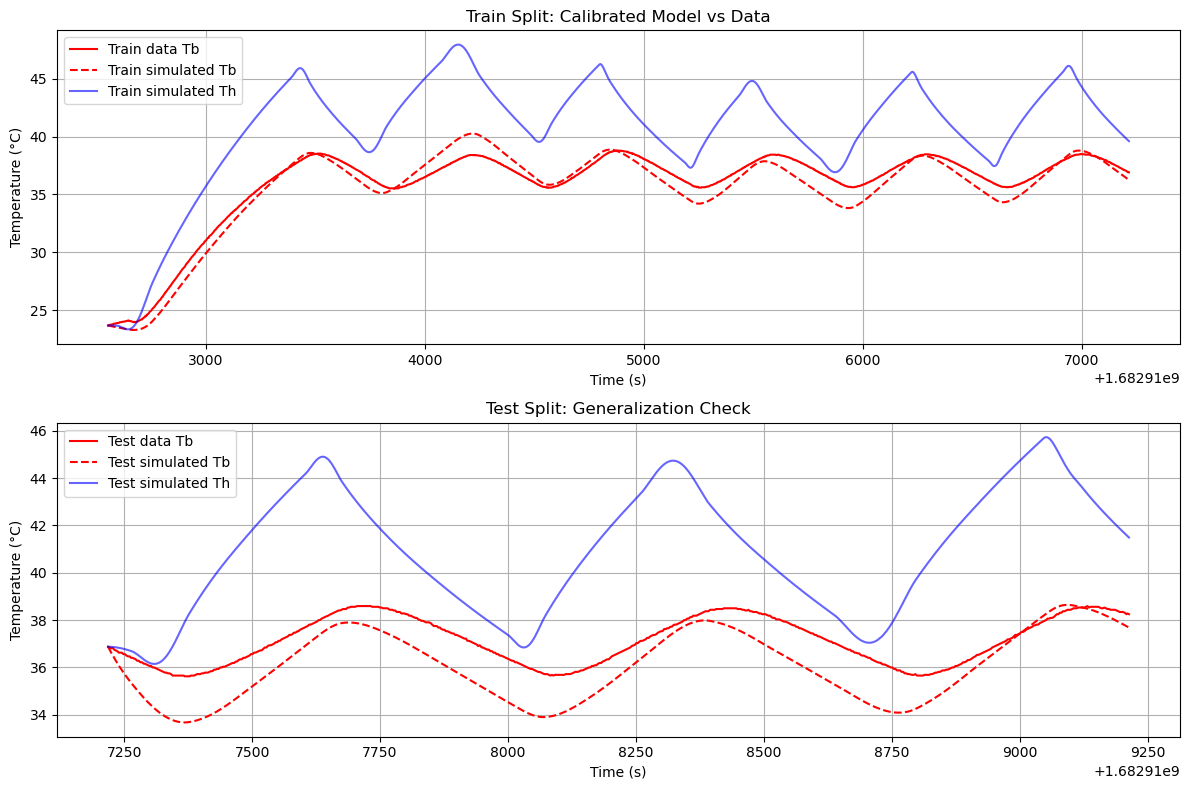

In [12]:
optimal_parameters = res.x

train_sol = simulate_with_params(
    optimal_parameters, train_time, train_room_lookup, train_heater_lookup, train_y0
)
test_sol = simulate_with_params(
    optimal_parameters, test_time, test_room_lookup, test_heater_lookup, test_y0
)

plt.figure(figsize=(12, 8))

# Train segment
plt.subplot(2, 1, 1)
plt.plot(train_time, train_avg_temp, color='red', label='Train data Tb')
plt.plot(train_time, train_sol.y[1, :], color='red', linestyle='--', label='Train simulated Tb')
plt.plot(train_time, train_sol.y[0, :], color='blue', alpha=0.6, label='Train simulated Th')
plt.title('Train Split: Calibrated Model vs Data')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.legend()

# Test segment
plt.subplot(2, 1, 2)
plt.plot(test_time, test_avg_temp, color='red', label='Test data Tb')
plt.plot(test_time, test_sol.y[1, :], color='red', linestyle='--', label='Test simulated Tb')
plt.plot(test_time, test_sol.y[0, :], color='blue', alpha=0.6, label='Test simulated Th')
plt.title('Test Split: Generalization Check')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Note how the calibration is not perfect. This is often the case, since our model simplifies the physics by quite a bit!

Also note how we now have a way to predict the heater temperature, even though we do not have a sensor for it. Our calibration would be improved if we had sensor data for the heater temperature, but we can be reasonably confident in our predictions of it, since the box temperatures are aligned.

## Exercises

1. Go back to the notebook [3-Physics-Modelling\2-ModellingIncubatorDynamics.ipynb](../3-Physics-Modelling\2-ModellingIncubatorDynamics.ipynb) and adjust the parameters of the model there, so that you can get a more realistic impression of how the controller works. Then adjust the controller parameters to ensure it works better (e.g., does not overshoot the maximum or undershoot the minimum temperature so much.)
2. Compare the above calibration code with the training of the neural network in [3-Physics-Modelling\4-TrainingIncubatorNN.ipynb](../3-Physics-Modelling\4-TrainingIncubatorNN.ipynb). What are the similarities and differences?

* We dont know how the NN performs or interprets the value and what/why it predicts the next value. Not ideal for closed-loop.
* The optimization algoritm is hardcoded math - we can trace every decision back.
* Calibration in 4-CalibratingIncubatorDynamics.ipynb fits a physics-based ODE with a small set of physical parameters (Ch, Cb, G_hb, G_br, Voltage, Current).
* NN training in 4-TrainingIncubatorNN.ipynb learns many abstract weights without explicit physical meaning.
* Calibration can be expensive during fitting because each loss evaluation solves an ODE.
* NN training is expensive upfront, but inference is usually very fast once trained.


3. Just like in training of the neural network, we should have a training/test split of the data. Adjust the above code to do just that.

* Note how the model is trained on the ramp up, but the test data only shows repeated waves.
  Also, the `cost_train` function returns the SSE of the training data set, while the `Evaluate_cost` both returns the SEE of train and test data set. 